In [1]:
%load_ext autoreload
%autoreload 2
import sys
import os
ProjDIR = "/home/jw3514/Work/CellType_Psy/CellTypeBias_VIP/" # Change to your project directory
sys.path.insert(1, f'{ProjDIR}/src/')
sys.path.insert(1, '/home/jw3514/Work/UNIMED/src')
from CellType_PSY import *
from UNIMED import *
#import scanpy as sc
HGNC, ENSID2Entrez, GeneSymbol2Entrez, Entrez2Symbol = LoadGeneINFO()

try:
    os.chdir(f"{ProjDIR}/notebooks/")
    print(f"Current working directory: {os.getcwd()}")
except FileNotFoundError as e:
    print(f"Error: Could not change directory - {e}")
except Exception as e:
    print(f"Unexpected error: {e}")

Current working directory: /home/jw3514/Work/CellType_Psy/CellTypeBias_VIP/notebooks


In [30]:
HumanCT_Z2_HCT = pd.read_csv("/home/jw3514/Work/CellType_Psy/dat/HumanCTExpressionMats/HumanCT.TPM.0.1.Filt.Spec.clip.lowexp.cut1e4.csv", index_col=0)
HumanCT_Z2_HCT.columns = HumanCT_Z2_HCT.columns.astype(int)
HumanCT_Z2_HCT.shape

(16049, 461)

In [4]:
GeneWeightDIR = "../dat/GeneWeights/"
Bias_Save_Dir = "/home/jw3514/Work/CellType_Psy/CellTypeBias_VIP/dat/Spec_Bias_Jul07/"
if not os.path.exists(Bias_Save_Dir): # make dir if not exists
    os.makedirs(Bias_Save_Dir)

In [41]:
SCZ_Bias = pd.read_csv("{}/HCT.SCZ61.addP.csv".format(Bias_Save_Dir), index_col=0)

In [22]:
# The file has no header row, so treat all rows as data and provide a custom header
custom_header = ["Weight"]
GeneWeights = pd.read_csv(
    f"{GeneWeightDIR}SCZ.top500.nopLI.LGD_Dmis_SameWeight.exclude_Mis2.gw",
    index_col=0,
    header=None,
    names=custom_header,
)

GeneWeights.head()

,Weight
9739,16.255934
8454,9.750848
23039,12.501695
7204,14.013563
8913,13.764411


In [17]:
GeneDF = pd.read_csv("../dat/SCZ.ALLGENE.MutCountModified.csv", index_col=0)

In [18]:
GeneDF.head(2)

,Gene Symbol,Gene Name,Case PTV,Ctrl PTV,Case mis3,Ctrl mis3,Case mis2,Ctrl mis2,P ca/co (Class 1),P ca/co (Class 2),...,pLI,nLGD,nMis3,nMis2,LGD_OR,Mis3_OR,Mis2_OR,LGD_pen,Mis3_pen,Mis2_pen
Entrez,,,,,,,,,,,,,,,,,,,,,
9739.0,SETD1A,SET domain containing 1A,15.0,3.0,3.0,4.0,11,10,3.600000e-07,0.000588,...,1.0,14.252543,2.003391,8.508477,19.064378,3.211252,4.380156,0.067661,0.014307,0.019408
8454.0,CUL1,Cullin 1,8.0,1.0,2.0,0.0,7,16,1.010000e-05,0.261000,...,1.0,7.750848,2.000000,3.013563,21.067577,12.042194,1.889051,0.075481,0.051619,0.008466


In [12]:
GeneDF.columns

Index(['Gene Symbol', 'Gene Name', 'Case PTV', 'Ctrl PTV', 'Case mis3',
       'Ctrl mis3', 'Case mis2', 'Ctrl mis2', 'P ca/co (Class 1)',
       'P ca/co (Class 2)', 'P ca/co (comb)', 'De novo PTV', 'De novo mis3',
       'De novo mis2', 'P de novo', 'P meta', 'Q meta', 'OR (PTV)',
       'OR (Class I)', 'OR (Class II)', 'Case syn', 'Ctrl syn',
       'P ca/co (syn)', 'P meta, no gnomAD', 'Case/Ctrl PTV, no gnomAD',
       'Case/Ctrl mis3, no gnomAD', 'Case/Ctrl mis2, no gnomAD',
       'P ca/co (Class I), no gnomAD', 'P ca/co (Class II), no gnomAD',
       'P ca/co (comb), no gnomAD', 'pLI', 'nLGD', 'nMis3', 'nMis2', 'LGD_OR',
       'Mis3_OR', 'Mis2_OR', 'LGD_pen', 'Mis3_pen', 'Mis2_pen'],
      dtype='object')

In [27]:
for i, row in GeneWeights.iterrows():
    if i in GeneDF.index.values:
        GeneWeights.loc[i, "Pval"] = GeneDF.loc[i, "P meta"]
        GeneWeights.loc[i, "FDR"] = GeneDF.loc[i, "Q meta"]
        GeneWeights.loc[i, "Gene Symbol"] = GeneDF.loc[i, "Gene Symbol"]

In [28]:
GeneWeights

,Weight,FDR,Pval,Gene Symbol
9739,16.255934,3.620000e-08,2.000000e-12,SETD1A
8454,9.750848,1.820000e-05,2.010000e-09,CUL1
23039,12.501695,4.340000e-05,7.180000e-09,XPO7
7204,14.013563,2.880000e-04,6.350000e-08,TRIO
8913,13.764411,1.540000e-03,4.570000e-07,CACNA1G
...,...,...,...,...
10444,1.750848,8.710000e-01,2.480000e-02,ZER1
54542,4.255934,8.710000e-01,2.490000e-02,RC3H2
129138,3.505086,8.710000e-01,2.500000e-02,ANKRD54
3487,3.252543,8.710000e-01,2.500000e-02,IGFBP4


In [144]:
# Calculate correlation as genes are removed, sorted by LofZ (descending)
GeneIdx, Corr_SCZ, Pval_SCZ = [], [], []
GeneIdx = np.arange(10, 200)
for i in GeneIdx:
    tmp_SCZ_GW = dict(zip(GeneWeights.index.values[:i], GeneWeights["Weight"].values[:i]))
    tmp_SCZ_Bias = HumanCT_AvgZ_Weighted(HumanCT_Z2_HCT, tmp_SCZ_GW)
    tmp_SCZ_Bias = AnnotateCTDat(tmp_SCZ_Bias, Anno)
    r, p = GetSingeCellBiasCorr(SCZ_Bias, tmp_SCZ_Bias, efflabel="EFFECT")
        
    Corr_SCZ.append(r)
    Pval_SCZ.append(p)



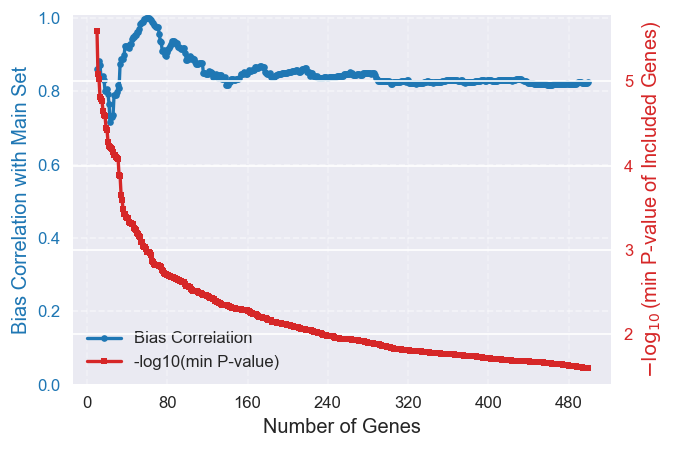

In [69]:
import matplotlib.ticker as mticker

GeneSig = GeneWeights["Pval"].values[GeneIdx]
GeneSig = -np.log10(GeneSig)

fig, ax1 = plt.subplots(figsize=(6, 4), dpi=120)

# Plot correlation
color_corr = '#1f77b4'
ax1.plot(GeneIdx, Corr, color=color_corr, linewidth=2, marker='o', markersize=4, label='Bias Correlation')
ax1.set_xlabel("Number of Genes", fontsize=12)
ax1.set_ylabel("Bias Correlation with Main Set", color=color_corr, fontsize=12)
ax1.tick_params(axis='y', labelcolor=color_corr)
ax1.set_ylim(0, 1.01)
ax1.yaxis.set_major_locator(mticker.MultipleLocator(0.2))
# Use original (linear) scale for x-axis
# ax1.set_xscale('log')  # Removed log scale
ax1.xaxis.set_major_locator(mticker.MaxNLocator(integer=True, nbins=8))
ax1.xaxis.set_minor_locator(mticker.AutoMinorLocator())
ax1.xaxis.set_minor_formatter(mticker.NullFormatter())
ax1.grid(True, which='major', axis='y', linestyle='--', alpha=0.5)
ax1.grid(True, which='major', axis='x', linestyle='--', alpha=0.3)

# Plot -log10(P-value) on secondary axis
ax2 = ax1.twinx()
color_pval = '#d62728'
ax2.plot(GeneIdx, GeneSig, color=color_pval, linewidth=2, marker='s', markersize=4, label='-log10(min P-value)')
ax2.set_ylabel(r"$-\log_{10}$(min P-value of Included Genes)", color=color_pval, fontsize=12)
ax2.tick_params(axis='y', labelcolor=color_pval)
ax2.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# Add legend in the bottom left
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='lower left', fontsize=10, frameon=False)

# Publication style tweaks
fig.tight_layout(pad=2)
for spine in ax1.spines.values():
    spine.set_linewidth(1.2)
for spine in ax2.spines.values():
    spine.set_linewidth(1.2)
plt.subplots_adjust(top=0.95, right=0.88)

plt.show()

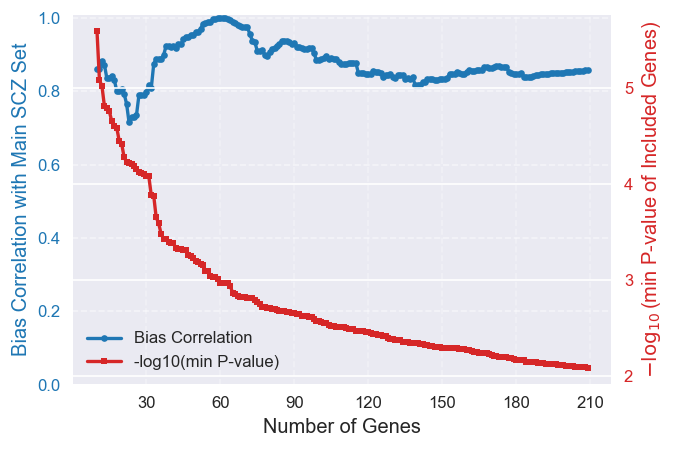

In [72]:
import matplotlib.ticker as mticker

# Show only the top 200 points
n_points = 200
GeneIdx_top = GeneIdx[:n_points]
Corr_top = Corr[:n_points]
GeneSig_top = GeneWeights["Pval"].values[GeneIdx_top]
GeneSig_top = -np.log10(GeneSig_top)

fig, ax1 = plt.subplots(figsize=(6, 4), dpi=120)

# Plot correlation
color_corr = '#1f77b4'
ax1.plot(GeneIdx_top, Corr_top, color=color_corr, linewidth=2, marker='o', markersize=4, label='Bias Correlation')
ax1.set_xlabel("Number of Genes", fontsize=12)
ax1.set_ylabel("Bias Correlation with Main SCZ Set", color=color_corr, fontsize=12)
ax1.tick_params(axis='y', labelcolor=color_corr)
ax1.set_ylim(0, 1.01)
ax1.yaxis.set_major_locator(mticker.MultipleLocator(0.2))
# Use original (linear) scale for x-axis
# ax1.set_xscale('log')  # Removed log scale
ax1.xaxis.set_major_locator(mticker.MaxNLocator(integer=True, nbins=8))
ax1.xaxis.set_minor_locator(mticker.AutoMinorLocator())
ax1.xaxis.set_minor_formatter(mticker.NullFormatter())
ax1.grid(True, which='major', axis='y', linestyle='--', alpha=0.5)
ax1.grid(True, which='major', axis='x', linestyle='--', alpha=0.3)

# Plot -log10(P-value) on secondary axis
ax2 = ax1.twinx()
color_pval = '#d62728'
ax2.plot(GeneIdx_top, GeneSig_top, color=color_pval, linewidth=2, marker='s', markersize=4, label='-log10(min P-value)')
ax2.set_ylabel(r"$-\log_{10}$(min P-value of Included Genes)", color=color_pval, fontsize=12)
ax2.tick_params(axis='y', labelcolor=color_pval)
ax2.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# Add legend in the bottom left
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='lower left', fontsize=10, frameon=False)

# Publication style tweaks
fig.tight_layout(pad=2)
for spine in ax1.spines.values():
    spine.set_linewidth(1.2)
for spine in ax2.spines.values():
    spine.set_linewidth(1.2)
plt.subplots_adjust(top=0.95, right=0.88)

plt.show()

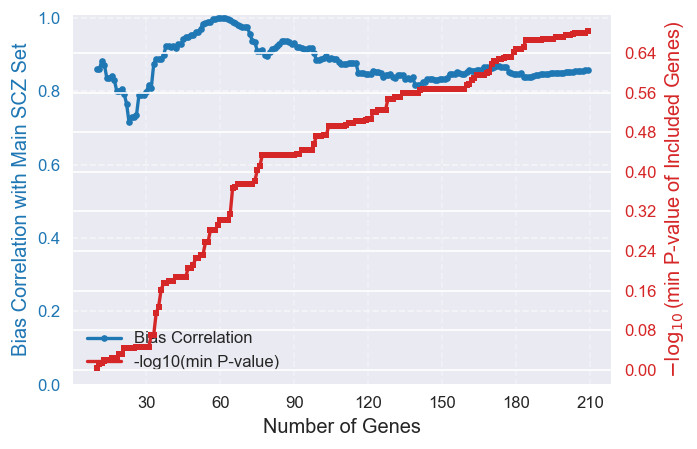

In [73]:
import matplotlib.ticker as mticker

# Show only the top 200 points
n_points = 200
GeneIdx_top = GeneIdx[:n_points]
Corr_top = Corr[:n_points]
GeneSig_top = GeneWeights["FDR"].values[GeneIdx_top]
#GeneSig_top = -np.log10(GeneSig_top)

fig, ax1 = plt.subplots(figsize=(6, 4), dpi=120)

# Plot correlation
color_corr = '#1f77b4'
ax1.plot(GeneIdx_top, Corr_top, color=color_corr, linewidth=2, marker='o', markersize=4, label='Bias Correlation')
ax1.set_xlabel("Number of Genes", fontsize=12)
ax1.set_ylabel("Bias Correlation with Main SCZ Set", color=color_corr, fontsize=12)
ax1.tick_params(axis='y', labelcolor=color_corr)
ax1.set_ylim(0, 1.01)
ax1.yaxis.set_major_locator(mticker.MultipleLocator(0.2))
# Use original (linear) scale for x-axis
# ax1.set_xscale('log')  # Removed log scale
ax1.xaxis.set_major_locator(mticker.MaxNLocator(integer=True, nbins=8))
ax1.xaxis.set_minor_locator(mticker.AutoMinorLocator())
ax1.xaxis.set_minor_formatter(mticker.NullFormatter())
ax1.grid(True, which='major', axis='y', linestyle='--', alpha=0.5)
ax1.grid(True, which='major', axis='x', linestyle='--', alpha=0.3)

# Plot -log10(P-value) on secondary axis
ax2 = ax1.twinx()
color_pval = '#d62728'
ax2.plot(GeneIdx_top, GeneSig_top, color=color_pval, linewidth=2, marker='s', markersize=4, label='-log10(min P-value)')
ax2.set_ylabel(r"$-\log_{10}$(min P-value of Included Genes)", color=color_pval, fontsize=12)
ax2.tick_params(axis='y', labelcolor=color_pval)
ax2.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# Add legend in the bottom left
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='lower left', fontsize=10, frameon=False)

# Publication style tweaks
fig.tight_layout(pad=2)
for spine in ax1.spines.values():
    spine.set_linewidth(1.2)
for spine in ax2.spines.values():
    spine.set_linewidth(1.2)
plt.subplots_adjust(top=0.95, right=0.88)

plt.show()

# ASD

In [78]:
HIQ_Bias = pd.read_csv("{}/HCT.ASD61.HIQ.addP.csv".format(Bias_Save_Dir), index_col=0)
LIQ_Bias = pd.read_csv("{}/HCT.ASD61.LIQ.addP.csv".format(Bias_Save_Dir), index_col=0)

HIQ_Bias.head()
LIQ_Bias.head()

,EFFECT,Rank,Class,Supercluster,Subtype,Neurotransmitter,Top three regions,Top three dissections,Number of cells,Neuropeptide auto-annotation,P-value,Z-score,EFFECT_adj,q-value,-logP
200,0.360425,1,NEUR,Hippocampal dentate gyrus,DG-GRAN,VGLUT1,"Hippocampus: 99.4%, Thalamus: 0.5%, Midbrain: ...","Human CA4C-DGC: 59.1%, Human DGR-CA4Rpy: 18.1%...",23293.0,CBLN CHGB GRP NAMPT NUCB PDYN proSAAS,0.0001,4.121555,0.360110,0.015365,4.000043
201,0.356477,2,NEUR,Hippocampal dentate gyrus,DG-GRAN,VGLUT1,"Hippocampus: 99.9%, Midbrain: 0.1%, Thalamus: ...","Human DGU-CA4Upy: 34.3%, Human DGR-CA4: 34.3%,...",18996.0,CBLN CHGB GRP IGF NAMPT NUCB PDYN UBL proSAAS,0.0003,3.983145,0.356045,0.017286,3.522922
403,0.344719,3,NEUR,Splatter,NaN,GABA,"Cerebral cortex: 45.6%, Amygdala: 33.5%, Hypot...","Human AON: 25.7%, Human CoA: 18.1%, Human Pir:...",2608.0,CCK CHGB CORT NAMPT NUCB NXPH PENK SCG TAC VGF...,0.0001,4.084140,0.344604,0.015365,4.000043
202,0.341684,4,NEUR,Hippocampal dentate gyrus,DG-GRAN,VGLUT1,"Hippocampus: 100.0%, Cerebral cortex: 0.0%, Am...","Human DGR-CA4Rpy: 87.7%, Human CA1R-CA2R-CA3R:...",398.0,CBLN CHGB GRP NAMPT NUCB UBL proSAAS,0.0005,3.777112,0.341660,0.017286,3.301073
136,0.333657,5,NEUR,Deep-layer intratelencephalic,NaN,VGLUT1 VGLUT2,"Amygdala: 54.6%, Cerebral cortex: 36.2%, Hypot...","Human CoA: 54.6%, Human AON: 28.3%, Human HTHs...",152.0,ADCYAP CBLN CCK CHGA CHGB CRH NAMPT NUCB PYY S...,0.0004,3.801122,0.334637,0.017286,3.397983


In [88]:
Spark_Denovo = pd.read_excel("../dat/41588_2022_1148_MOESM4_ESM.xlsx",
                           skiprows=2, sheet_name="Table S7")
Spark_Denovo = Spark_Denovo[Spark_Denovo[
    "pDenovoWEST_Meta"]!="."]
Spark_Denovo.shape

(378, 56)

In [89]:
Spark_Denovo.head(2)

,GeneID,EntrezID,HGNC,CytoBand,ExACpLI,LoFOvsE,LOEUF,LOEUFbin,SynOvsE,sHet,...,AllExpected_Meta,pAllEnrich_Meta,MisObserved_Meta,MisExpected_Meta,pMisEnrich_Meta,MisEvents_Meta,MisDist_Meta,pMisCluster_Meta,pMisComb_Meta,pDenovoWEST_Meta
0,ENSG00000119772,1788,DNMT3A,2p23.3,0.0,1.255000,1.581,8,0.94788,0.002902,...,0.163614,0.0,2.08,0.133761,0.0,16,178,0.0,0.0,0.0
1,ENSG00000143442,23126,POGZ,1q21.3,1,0.045859,0.119,0,0.97057,0.214955,...,0.418751,0.0,0.396,0.222332,0.2,4,170.7,0.00691,0.01,0.0


In [96]:
Spark_Denovo.columns

Index(['GeneID', 'EntrezID', 'HGNC', 'CytoBand', 'ExACpLI', 'LoFOvsE', 'LOEUF',
       'LOEUFbin', 'SynOvsE', 'sHet', 'Arisk', 'forecASD', 'SFARICategory',
       'SFARIScore', 'DDDCategory', 'DDDAllelic', 'DDDMutCons', 'DDDOrgan',
       'AutismMerged_LoF', 'AutismMerged_LoF_Rate', 'Simplex_LoF',
       'Simplex_LoF_Rate', 'Multiplex_LoF', 'Multiplex_LoF_Rate', 'NDD_LoF',
       'NDD_LoF_Rate', 'Control_LoF', 'AutismMerged_Dmis_REVEL0.5',
       'AutismMerged_Dmis_REVEL0.5_Rate', 'Simplex_Dmis_REVEL0.5',
       'Simplex_Dmis_REVEL0.5_Rate', 'Multiplex_Dmis_REVEL0.5',
       'Multiplex_Dmis_REVEL0.5_Rate', 'NDD_Dmis_REVEL0.5',
       'NDD_Dmis_REVEL0.5_Rate', 'Control_Dmis_REVEL0.5',
       'AutismMerged_Bmis_REVEL0.5', 'AutismMerged_Bmis_REVEL0.5_Rate',
       'Simplex_Bmis_REVEL0.5', 'Simplex_Bmis_REVEL0.5_Rate',
       'Multiplex_Bmis_REVEL0.5', 'Multiplex_Bmis_REVEL0.5_Rate',
       'NDD_Bmis_REVEL0.5', 'NDD_Bmis_REVEL0.5_Rate', 'Control_Bmis_REVEL0.5',
       'AllObserved_Meta', '

In [93]:
Mut_n_IQ = pd.read_csv("../dat/ASD_IQ_Mut.csv")
HighIQMuts_ALL = Mut_n_IQ[Mut_n_IQ["IQ"]>70]
LowIQMuts_ALL = Mut_n_IQ[Mut_n_IQ["IQ"]<=70]

In [100]:
LowIQMuts_ALL.head(2)

,IID,Sex,Pheno,VarID,GeneID,HGNC,GeneEff,REVEL,ExACpLI,Entrez,IQ
6,AU201A,Male,Affected,2:173898693:G:A,ENSG00000091428,RAPGEF4,splice_donor,.,0.95722585,11069,64.0
7,AU084A,Female,Affected,21:41648022:A:C,ENSG00000171587,DSCAM,splice_donor,.,1,1826,52.0


In [94]:
HighIQMuts_ALL.shape

(1149, 11)

In [95]:
LowIQMuts_ALL.shape

(713, 11)

In [115]:
Spark_Denovo_sub = Spark_Denovo[["EntrezID", "HGNC", "pDenovoWEST_Meta", "AutismMerged_LoF", "AutismMerged_Dmis_REVEL0.5"]]
Spark_Denovo_sub = Spark_Denovo_sub.set_index("EntrezID")
for i, row in Spark_Denovo_sub.iterrows():
    LIQ_counts = LowIQMuts_ALL[LowIQMuts_ALL["Entrez"]==i].shape[0]
    HIQ_counts = HighIQMuts_ALL[HighIQMuts_ALL["Entrez"]==i].shape[0]
    Spark_Denovo_sub.loc[i, "LIQ_counts"] = LIQ_counts
    Spark_Denovo_sub.loc[i, "HIQ_counts"] = HIQ_counts
    if row["pDenovoWEST_Meta"] == 0:
        Spark_Denovo_sub.loc[i, "pDenovoWEST_Meta"] = 1e-6
    

In [117]:
Spark_Denovo_sub.head(20)

,HGNC,pDenovoWEST_Meta,AutismMerged_LoF,AutismMerged_Dmis_REVEL0.5,LIQ_counts,HIQ_counts
EntrezID,,,,,,
1788,DNMT3A,0.0,2,11,2.0,3.0
23126,POGZ,0.0,12,0,0.0,3.0
6326,SCN2A,0.0,23,20,9.0,3.0
9024,BRSK2,0.0,6,2,0.0,0.0
4204,MECP2,0.0,7,13,3.0,1.0
64599,GIGYF1,0.0,11,0,1.0,4.0
6529,SLC6A1,0.0,2,12,5.0,2.0
2904,GRIN2B,0.0,7,4,3.0,1.0
5728,PTEN,0.0,9,17,5.0,2.0


In [118]:
# Calculate correlation as genes are removed, sorted by LofZ (descending)
GeneIdx_HIQ, Corr_HIQ, Pval_HIQ = [], [], []
#GeneIdx_LIQ, Corr_LIQ, Pval_LIQ = [], [], []
GeneIdx = np.arange(10, 200)
for i in GeneIdx:
    tmp_HIQ_ASD_GW = dict(zip(Spark_Denovo_sub.index.values[:i], Spark_Denovo_sub["HIQ_counts"].values[:i]))
    tmp_HIQ_ASD_Bias = HumanCT_AvgZ_Weighted(HumanCT_Z2_HCT, tmp_HIQ_ASD_GW)
    tmp_HIQ_ASD_Bias = AnnotateCTDat(tmp_HIQ_ASD_Bias, Anno)
    r, p = GetSingeCellBiasCorr(HIQ_Bias, tmp_HIQ_ASD_Bias, efflabel="EFFECT")
        
    Corr_HIQ.append(r)
    Pval_HIQ.append(p)

In [119]:
# Calculate correlation as genes are removed, sorted by LofZ (descending)
GeneIdx_LIQ, Corr_LIQ, Pval_LIQ = [], [], []
GeneIdx = np.arange(10, 200)
for i in GeneIdx:
    tmp_LIQ_ASD_GW = dict(zip(Spark_Denovo_sub.index.values[:i], Spark_Denovo_sub["LIQ_counts"].values[:i]))
    tmp_LIQ_ASD_Bias = HumanCT_AvgZ_Weighted(HumanCT_Z2_HCT, tmp_LIQ_ASD_GW)
    tmp_LIQ_ASD_Bias = AnnotateCTDat(tmp_LIQ_ASD_Bias, Anno)
    r, p = GetSingeCellBiasCorr(LIQ_Bias, tmp_LIQ_ASD_Bias, efflabel="EFFECT")
        
    Corr_LIQ.append(r)
    Pval_LIQ.append(p)

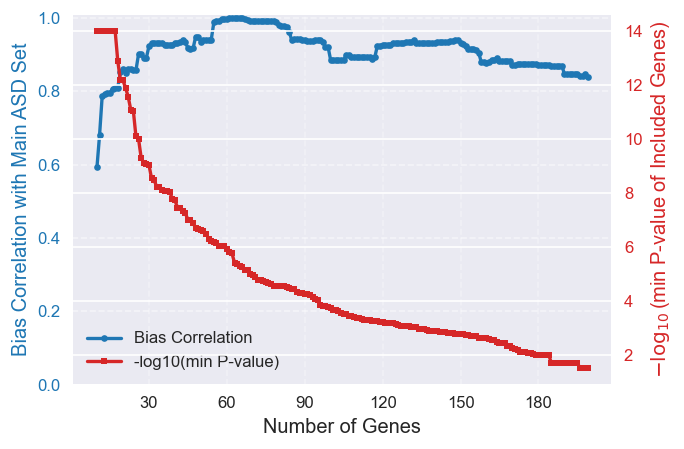

In [126]:
import matplotlib.ticker as mticker

# Show only the top 200 points
n_points = 200
GeneIdx_top = GeneIdx
Corr_top = Corr_HIQ
GeneSig_top = Spark_Denovo_sub["pDenovoWEST_Meta"].values[GeneIdx_top]
GeneSig_top = -np.log10(np.array(GeneSig_top, dtype=np.float64))

fig, ax1 = plt.subplots(figsize=(6, 4), dpi=120)

# Plot correlation
color_corr = '#1f77b4'
ax1.plot(GeneIdx_top, Corr_top, color=color_corr, linewidth=2, marker='o', markersize=4, label='Bias Correlation')
ax1.set_xlabel("Number of Genes", fontsize=12)
ax1.set_ylabel("Bias Correlation with Main ASD Set", color=color_corr, fontsize=12)
ax1.tick_params(axis='y', labelcolor=color_corr)
ax1.set_ylim(0, 1.01)
ax1.yaxis.set_major_locator(mticker.MultipleLocator(0.2))
# Use original (linear) scale for x-axis
# ax1.set_xscale('log')  # Removed log scale
ax1.xaxis.set_major_locator(mticker.MaxNLocator(integer=True, nbins=8))
ax1.xaxis.set_minor_locator(mticker.AutoMinorLocator())
ax1.xaxis.set_minor_formatter(mticker.NullFormatter())
ax1.grid(True, which='major', axis='y', linestyle='--', alpha=0.5)
ax1.grid(True, which='major', axis='x', linestyle='--', alpha=0.3)

# Plot -log10(P-value) on secondary axis
ax2 = ax1.twinx()
color_pval = '#d62728'
ax2.plot(GeneIdx_top, GeneSig_top, color=color_pval, linewidth=2, marker='s', markersize=4, label='-log10(min P-value)')
ax2.set_ylabel(r"$-\log_{10}$(min P-value of Included Genes)", color=color_pval, fontsize=12)
ax2.tick_params(axis='y', labelcolor=color_pval)
ax2.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# Add legend in the bottom left
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='lower left', fontsize=10, frameon=False)

# Publication style tweaks
fig.tight_layout(pad=2)
for spine in ax1.spines.values():
    spine.set_linewidth(1.2)
for spine in ax2.spines.values():
    spine.set_linewidth(1.2)
plt.subplots_adjust(top=0.95, right=0.88)

plt.show()

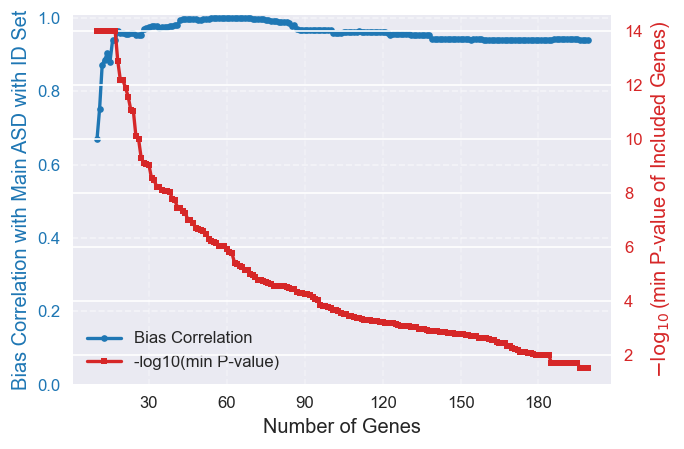

In [127]:
import matplotlib.ticker as mticker

# Show only the top 200 points
n_points = 200
GeneIdx_top = GeneIdx
Corr_top = Corr_LIQ
GeneSig_top = Spark_Denovo_sub["pDenovoWEST_Meta"].values[GeneIdx_top]
GeneSig_top = -np.log10(np.array(GeneSig_top, dtype=np.float64))

fig, ax1 = plt.subplots(figsize=(6, 4), dpi=120)

# Plot correlation
color_corr = '#1f77b4'
ax1.plot(GeneIdx_top, Corr_top, color=color_corr, linewidth=2, marker='o', markersize=4, label='Bias Correlation')
ax1.set_xlabel("Number of Genes", fontsize=12)
ax1.set_ylabel("Bias Correlation with Main ASD with ID Set", color=color_corr, fontsize=12)
ax1.tick_params(axis='y', labelcolor=color_corr)
ax1.set_ylim(0, 1.01)
ax1.yaxis.set_major_locator(mticker.MultipleLocator(0.2))
# Use original (linear) scale for x-axis
# ax1.set_xscale('log')  # Removed log scale
ax1.xaxis.set_major_locator(mticker.MaxNLocator(integer=True, nbins=8))
ax1.xaxis.set_minor_locator(mticker.AutoMinorLocator())
ax1.xaxis.set_minor_formatter(mticker.NullFormatter())
ax1.grid(True, which='major', axis='y', linestyle='--', alpha=0.5)
ax1.grid(True, which='major', axis='x', linestyle='--', alpha=0.3)

# Plot -log10(P-value) on secondary axis
ax2 = ax1.twinx()
color_pval = '#d62728'
ax2.plot(GeneIdx_top, GeneSig_top, color=color_pval, linewidth=2, marker='s', markersize=4, label='-log10(min P-value)')
ax2.set_ylabel(r"$-\log_{10}$(min P-value of Included Genes)", color=color_pval, fontsize=12)
ax2.tick_params(axis='y', labelcolor=color_pval)
ax2.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# Add legend in the bottom left
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='lower left', fontsize=10, frameon=False)

# Publication style tweaks
fig.tight_layout(pad=2)
for spine in ax1.spines.values():
    spine.set_linewidth(1.2)
for spine in ax2.spines.values():
    spine.set_linewidth(1.2)
plt.subplots_adjust(top=0.95, right=0.88)

plt.show()

# DDD

In [135]:
DDD_Bias = pd.read_csv("{}/HCT.DDD.top61.addP.csv".format(Bias_Save_Dir), index_col=0)

In [130]:
DDD_Genes = pd.read_excel("/home/jw3514/Work/data/DDD/41586_2020_2832_MOESM4_ESM.xlsx")
DDD_Genes = DDD_Genes.sort_values("denovoWEST_p_full")
entrez_ids = [int(GeneSymbol2Entrez.get(x, -1)) for x in DDD_Genes["symbol"].values]
DDD_Genes["EntrezID"] = entrez_ids
DDD_Genes.shape

(19654, 35)

In [131]:
DDD_Genes.columns

Index(['symbol', 'hgnc_id', 'chr', 'diagnostic_category',
       'coding_sequence_variant', 'frameshift_variant', 'inframe_deletion',
       'inframe_insertion', 'initiator_codon_variant', 'missense_variant',
       'splice_acceptor_variant', 'splice_donor_variant', 'stop_gained',
       'stop_lost', 'stop_retained_variant', 'synonymous_variant',
       'PTV_enrichment_p', 'power_median', 's_het', 'observed_full',
       'expected_full', 'enrich_all_p_full', 'enrich_mis_p_full',
       'cluster_p_full', 'denovoWEST_p_full', 'observed_ud', 'expected_ud',
       'enrich_all_p_ud', 'enrich_mis_p_ud', 'cluster_p_ud', 'denovoWEST_p_ud',
       'denovoWEST_p_ud_synmod', 'gnomad_oe_syn', 'significant', 'EntrezID'],
      dtype='object')

In [132]:
DDD_Genes.head(2)

,symbol,hgnc_id,chr,diagnostic_category,coding_sequence_variant,frameshift_variant,inframe_deletion,inframe_insertion,initiator_codon_variant,missense_variant,...,observed_ud,expected_ud,enrich_all_p_ud,enrich_mis_p_ud,cluster_p_ud,denovoWEST_p_ud,denovoWEST_p_ud_synmod,gnomad_oe_syn,significant,EntrezID
4148,CTCF,13723.0,16,consensus,0,6,0,0,0,19,...,0.001,0.822697,1.0,1.0,NaN,1.0,NaN,NaN,True,10664
15996,SOX11,11191.0,2,consensus,0,3,0,0,0,19,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,6664


In [ ]:
DDD_Genes_sub = DDD_Genes[["symbol", "EntrezID", "denovoWEST_p_full", "missense_variant", "frameshift_variant", "splice_acceptor_variant", "splice_donor_variant", "stop_gained", "stop_lost"]]
DDD_Genes_sub = 

In [134]:
DDD_Genes_sub

,symbol,EntrezID,denovoWEST_p_full,missense_variant,frameshift_variant,splice_acceptor_variant,splice_donor_variant,stop_gained,stop_lost
4148,CTCF,10664,1.525743e-26,19,6,0,2,1,0
15996,SOX11,6664,2.830596e-24,19,3,0,0,1,0
8477,KCNQ3,3786,2.173608e-22,18,1,0,0,0,0
12000,PACS2,23241,3.644186e-22,18,0,0,0,0,0
3696,CNOT3,4849,3.206936e-21,16,6,0,0,1,0
...,...,...,...,...,...,...,...,...,...
19642,ZWILCH,55055,NaN,0,0,0,0,0,0
19644,ZXDA,7789,NaN,0,0,0,0,0,0
19645,ZXDB,158586,NaN,0,0,0,0,0,0
19652,hsa-mir-1199,-1,NaN,0,0,0,0,0,0


In [137]:
# Calculate correlation as genes are removed, sorted by LofZ (descending)
Corr_DDD, Pval_DDD = [], []
#GeneIdx_LIQ, Corr_LIQ, Pval_LIQ = [], [], []
GeneIdx = np.arange(10, 200)
for i in GeneIdx:
    tmp = DDD_Genes_sub.head(i)
    tmp_DDD_GW = Aggregate_Gene_Weights_NDD(tmp)
    tmp_DDD_Bias = HumanCT_AvgZ_Weighted(HumanCT_Z2_HCT, tmp_DDD_GW)
    tmp_DDD_Bias = AnnotateCTDat(tmp_DDD_Bias, Anno)
    r, p = GetSingeCellBiasCorr(DDD_Bias, tmp_DDD_Bias, efflabel="EFFECT")
        
    Corr_DDD.append(r)
    Pval_DDD.append(p)

In [155]:
import matplotlib.ticker as mticker

def plot_gene_set_correlation(
    GeneIdx_top,
    Corr_top,
    GeneSig_top,
    corr_label="Bias Correlation",
    pval_label=r"$-\log_{10}$(min p-value of Included Genes)",
    xlabel="Number of Genes",
    ylabel_corr="Bias Correlation with Main ASD with ID Set",
    ylabel_pval=None,
    figsize=(6, 4),
    dpi=120,
    color_corr='#1f77b4',
    color_pval='#d62728',
    legend_loc='lower left',
    legend_fontsize=10,
    ylim_corr=(0, 1.01),
    nbins_x=8,
    title=None,
    ax1=None,
    ax2=None,
    show=True,
):
    """
    Plot gene set correlation and -log10(p-value) as a function of number of genes.

    Parameters
    ----------
    GeneIdx_top : array-like
        X-axis values (number of genes included).
    Corr_top : array-like
        Correlation values to plot on left y-axis.
    GeneSig_top : array-like
        -log10(p-value) values to plot on right y-axis.
    corr_label : str
        Label for the correlation line.
    pval_label : str
        Label for the p-value line.
    xlabel : str
        X-axis label.
    ylabel_corr : str
        Y-axis label for correlation.
    ylabel_pval : str or None
        Y-axis label for p-value. If None, uses pval_label.
    figsize : tuple
        Figure size.
    dpi : int
        Figure DPI.
    color_corr : str
        Color for correlation line.
    color_pval : str
        Color for p-value line.
    legend_loc : str
        Location for legend.
    legend_fontsize : int
        Font size for legend.
    ylim_corr : tuple
        Y-axis limits for correlation.
    nbins_x : int
        Number of bins for x-axis major ticks.
    title : str or None
        Optional plot title.
    ax1, ax2 : matplotlib axes or None
        Optionally provide axes to plot on.
    show : bool
        Whether to call plt.show().
    """
    import matplotlib.pyplot as plt

    if ax1 is None or ax2 is None:
        fig, ax1 = plt.subplots(figsize=figsize, dpi=dpi)
    else:
        fig = ax1.figure

    # Plot correlation
    ax1.plot(GeneIdx_top, Corr_top, color=color_corr, linewidth=2, marker='o', markersize=4, label=corr_label)
    ax1.set_xlabel(xlabel, fontsize=12)
    ax1.set_ylabel(ylabel_corr, color=color_corr, fontsize=12)
    ax1.tick_params(axis='y', labelcolor=color_corr)
    ax1.set_ylim(*ylim_corr)
    ax1.yaxis.set_major_locator(mticker.MultipleLocator(0.2))
    ax1.xaxis.set_major_locator(mticker.MaxNLocator(integer=True, nbins=nbins_x))
    ax1.xaxis.set_minor_locator(mticker.AutoMinorLocator())
    ax1.xaxis.set_minor_formatter(mticker.NullFormatter())

    # Only draw horizontal grid lines, and only behind the lines, not over text
    ax1.grid(True, which='major', axis='y', linestyle='--', alpha=0.5, zorder=1)
    # Remove x grid to avoid covering x-labels/ticks
    ax1.grid(False, which='major', axis='x', zorder=1, alpha=0.5)

    # Plot -log10(P-value) on secondary axis
    if ax2 is None:
        ax2 = ax1.twinx()
    ax2.plot(GeneIdx_top, GeneSig_top, color=color_pval, linewidth=2, marker='s', markersize=4, label=pval_label, zorder=3)
    ax2.set_ylabel(ylabel_pval if ylabel_pval is not None else pval_label, color=color_pval, fontsize=12)
    ax2.tick_params(axis='y', labelcolor=color_pval)
    ax2.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))

    # Add legend in the bottom left
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc=legend_loc, fontsize=legend_fontsize, frameon=False)

    # Publication style tweaks
    fig.tight_layout(pad=2)
    for spine in ax1.spines.values():
        spine.set_linewidth(1.2)
    for spine in ax2.spines.values():
        spine.set_linewidth(1.2)
    plt.subplots_adjust(top=0.95, right=0.88)
    if title is not None:
        ax1.set_title(title, fontsize=14, pad=10)
    if show:
        plt.show()
    return fig, ax1, ax2

/tmp/ipykernel_49746/903765744.py:90: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax1.grid(False, which='major', axis='x', zorder=1, alpha=0.5)


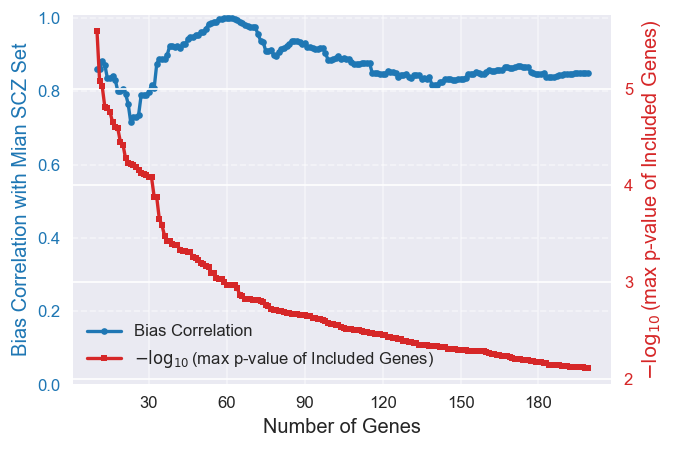

(<Figure size 720x480 with 2 Axes>,
 <Axes: xlabel='Number of Genes', ylabel='Bias Correlation with Mian SCZ Set'>,
 <Axes: ylabel='$-\\log_{10}$(max p-value of Included Genes)'>)

In [156]:
plot_gene_set_correlation(
    GeneIdx_top=GeneIdx,
    Corr_top=Corr_SCZ,
    GeneSig_top=-np.log10(np.array(GeneWeights["Pval"].values[GeneIdx], dtype=np.float64)),
    corr_label="Bias Correlation",
    ylabel_corr = "Bias Correlation with Mian SCZ Set",
    pval_label=r"$-\log_{10}$(max p-value of Included Genes)"
)

/tmp/ipykernel_49746/903765744.py:90: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax1.grid(False, which='major', axis='x', zorder=1, alpha=0.5)


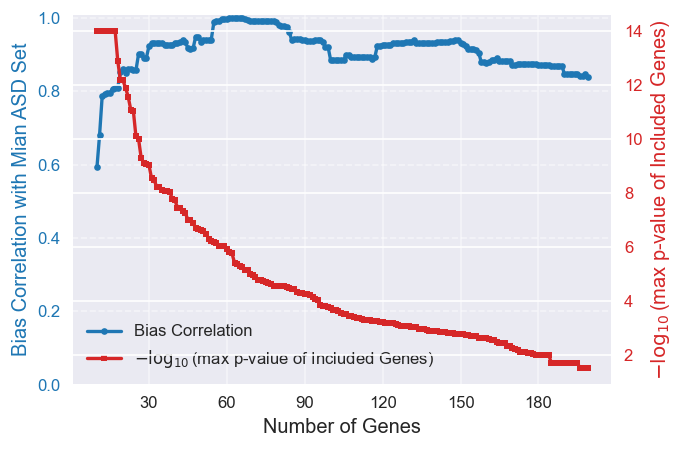

(<Figure size 720x480 with 2 Axes>,
 <Axes: xlabel='Number of Genes', ylabel='Bias Correlation with Mian ASD Set'>,
 <Axes: ylabel='$-\\log_{10}$(max p-value of Included Genes)'>)

In [157]:
plot_gene_set_correlation(
    GeneIdx_top=GeneIdx,
    Corr_top=Corr_HIQ,
    GeneSig_top=-np.log10(np.array(Spark_Denovo_sub["pDenovoWEST_Meta"].values[GeneIdx], dtype=np.float64)),
    corr_label="Bias Correlation",
    ylabel_corr = "Bias Correlation with Mian ASD Set",
    pval_label=r"$-\log_{10}$(max p-value of Included Genes)"
)

/tmp/ipykernel_49746/903765744.py:90: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax1.grid(False, which='major', axis='x', zorder=1, alpha=0.5)


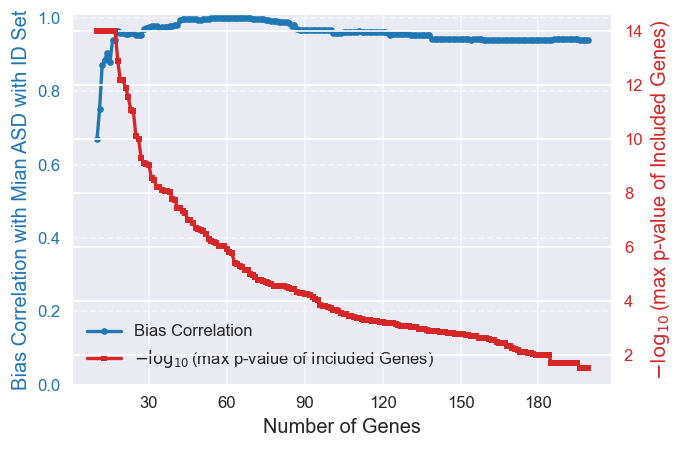

(<Figure size 720x480 with 2 Axes>,
 <Axes: xlabel='Number of Genes', ylabel='Bias Correlation with Mian ASD with ID Set'>,
 <Axes: ylabel='$-\\log_{10}$(max p-value of Included Genes)'>)

In [158]:
plot_gene_set_correlation(
    GeneIdx_top=GeneIdx,
    Corr_top=Corr_LIQ,
    GeneSig_top=-np.log10(np.array(Spark_Denovo_sub["pDenovoWEST_Meta"].values[GeneIdx], dtype=np.float64)),
    corr_label="Bias Correlation",
    ylabel_corr = "Bias Correlation with Mian ASD with ID Set",
    pval_label=r"$-\log_{10}$(max p-value of Included Genes)"
)

/tmp/ipykernel_49746/903765744.py:90: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax1.grid(False, which='major', axis='x', zorder=1, alpha=0.5)


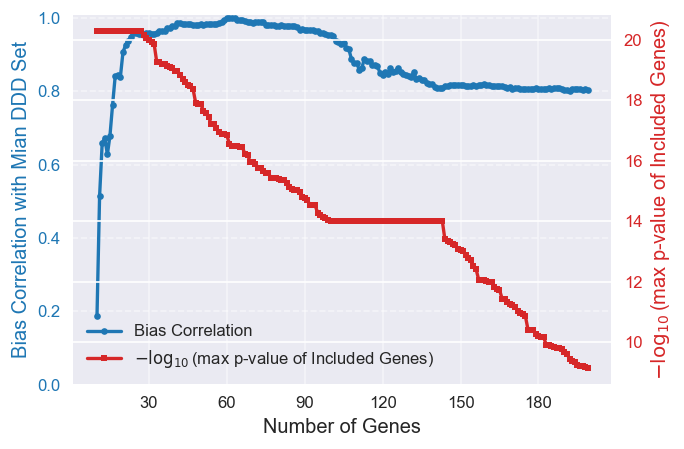

(<Figure size 720x480 with 2 Axes>,
 <Axes: xlabel='Number of Genes', ylabel='Bias Correlation with Mian DDD Set'>,
 <Axes: ylabel='$-\\log_{10}$(max p-value of Included Genes)'>)

In [159]:
plot_gene_set_correlation(
    GeneIdx_top=GeneIdx,
    Corr_top=Corr_DDD,
    GeneSig_top=-np.log10(np.array(DDD_Genes["denovoWEST_p_full"].values[GeneIdx], dtype=np.float64)),
    corr_label="Bias Correlation",
    ylabel_corr = "Bias Correlation with Mian DDD Set",
    pval_label=r"$-\log_{10}$(max p-value of Included Genes)"
)